In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/asvpoof-2019-dataset")

print("Path to dataset files:", path)

100%|██████████| 23.6G/23.6G [10:07<00:00, 41.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1


In [ ]:
import pandas as pd
import numpy as np
import os
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import kagglehub

# 1. Upgrade librosa for Colab compatibility
!pip install --upgrade librosa

# 2. Download/Locate the dataset using kagglehub
# This will return the path: /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1
path = kagglehub.dataset_download("awsaf49/asvpoof-2019-dataset")
BASE_PATH = path

# 3. --- DYNAMIC COLAB PATHS ---
# These now point to the kagglehub cache location automatically
LA_PROTOCOL = os.path.join(BASE_PATH, "LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt")
LA_AUDIO_DIR = os.path.join(BASE_PATH, "LA/LA/ASVspoof2019_LA_train/flac")

PA_PROTOCOL = os.path.join(BASE_PATH, "PA/PA/ASVspoof2019_PA_cm_protocols/ASVspoof2019.PA.cm.train.trn.txt")
PA_AUDIO_DIR = os.path.join(BASE_PATH, "PA/PA/ASVspoof2019_PA_train/flac")

# Create an output directory for your models and CSVs in Colab
WORKING_DIR = "/content/working"
os.makedirs(WORKING_DIR, exist_ok=True)

print(f"Dataset path: {BASE_PATH}")
print("Directories initialized. Ready to load protocols.")

Dataset path: /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1
Directories initialized. Ready to load protocols.


In [ ]:
# Define column names based on dataset documentation
cols = ['speaker_id', 'file_name', 'system_id', 'attack_type', 'label']

# 1. Load LA Protocol
# Note: Colab handles large CSVs well, this will be very fast
df_la = pd.read_csv(LA_PROTOCOL, sep=' ', header=None, names=cols)
df_la['task'] = 'LA'  # Tag as Deepfake task

# 2. Load PA Protocol
df_pa = pd.read_csv(PA_PROTOCOL, sep=' ', header=None, names=cols)
df_pa['task'] = 'PA'  # Tag as Replay task

# 3. Combine into one Master Dataframe
df_full = pd.concat([df_la, df_pa], ignore_index=True)

# 4. Create Numeric Labels (0 = Real, 1 = Fake)
# 0 = bonafide (Real), 1 = spoof (Fake)
df_full['target'] = (df_full['label'] == 'spoof').astype(int)

print(f"Total Combined Samples: {len(df_full)}")

print("\n--- Top 10 head samples ---")
print(df_full.head(10))

print("\n--- Top 10 tail samples ---")
print(df_full.tail(10))

# Quick check on the balance before we proceed to sampling
print("\n--- Class Counts (Imbalanced) ---")
print(df_full['label'].value_counts())

Total Combined Samples: 79380

--- Top 10 head samples ---
  speaker_id     file_name system_id attack_type     label task  target
0    LA_0079  LA_T_1138215         -           -  bonafide   LA       0
1    LA_0079  LA_T_1271820         -           -  bonafide   LA       0
2    LA_0079  LA_T_1272637         -           -  bonafide   LA       0
3    LA_0079  LA_T_1276960         -           -  bonafide   LA       0
4    LA_0079  LA_T_1341447         -           -  bonafide   LA       0
5    LA_0079  LA_T_1363611         -           -  bonafide   LA       0
6    LA_0079  LA_T_1596451         -           -  bonafide   LA       0
7    LA_0079  LA_T_1608170         -           -  bonafide   LA       0
8    LA_0079  LA_T_1684951         -           -  bonafide   LA       0
9    LA_0079  LA_T_1699801         -           -  bonafide   LA       0

--- Top 10 tail samples ---
      speaker_id     file_name system_id attack_type  label task  target
79370    PA_0098  PA_T_0053991       ccc       

/tmp/ipykernel_1136/1608018689.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=df_full, x='label', palette='viridis')


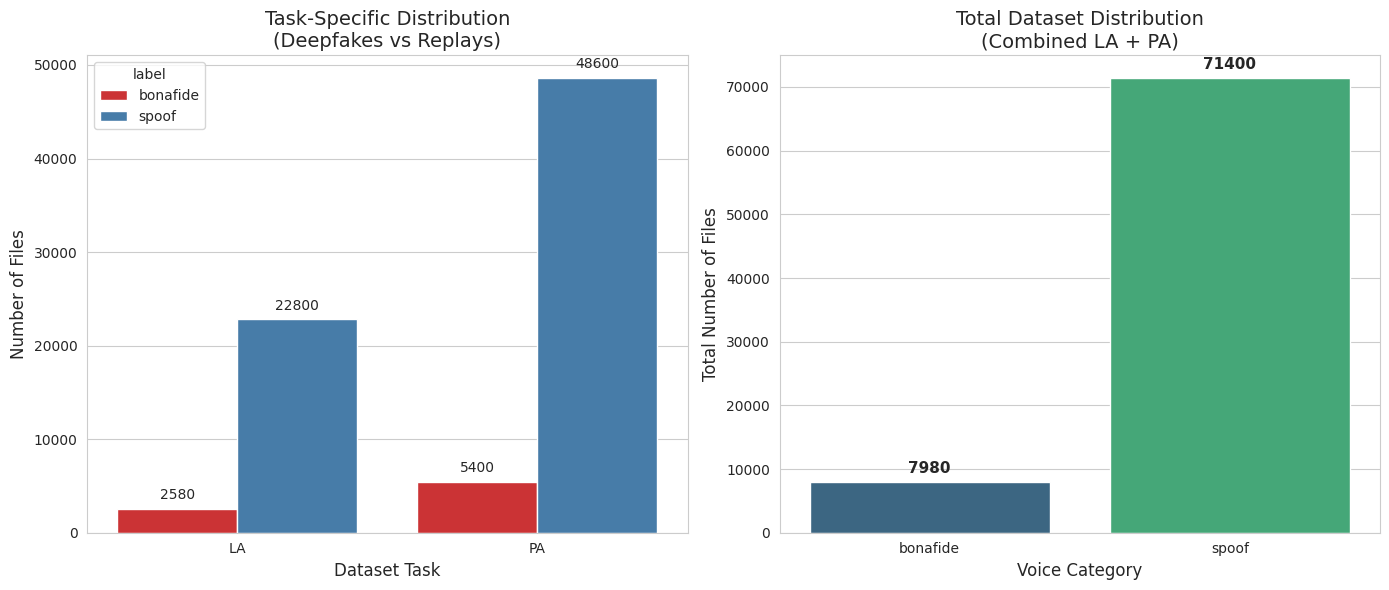

------------------------------
TOTAL REAL (Bona fide): 7980
TOTAL FAKE (Spoof):     71400
IMBALANCE RATIO:        8.95 fakes for every 1 real voice.
------------------------------
Observation: The fakes outnumber the real voices significantly. Balancing is required.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for a professional look (works great in Colab notebooks)
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# --- Plot 1: Breakdown by Task (LA vs PA) ---
plt.subplot(1, 2, 1)
# palette='Set1' gives distinct colors for Real vs Fake
ax1 = sns.countplot(data=df_full, x='task', hue='label', palette='Set1')
plt.title("Task-Specific Distribution\n(Deepfakes vs Replays)", fontsize=14)
plt.xlabel("Dataset Task", fontsize=12)
plt.ylabel("Number of Files", fontsize=12)

# Add counts on top of bars for Plot 1
for p in ax1.patches:
    if p.get_height() > 0: # Ensure we only label bars that exist
        ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)

# --- Plot 2: Total Combined (LA + PA) ---
plt.subplot(1, 2, 2)
ax2 = sns.countplot(data=df_full, x='label', palette='viridis')
plt.title("Total Dataset Distribution\n(Combined LA + PA)", fontsize=14)
plt.xlabel("Voice Category", fontsize=12)
plt.ylabel("Total Number of Files", fontsize=12)

# Add counts on top of bars for Plot 2
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print the exact numbers for your report
total_real = len(df_full[df_full['label'] == 'bonafide'])
total_fake = len(df_full[df_full['label'] == 'spoof'])
ratio = total_fake / total_real

print("-" * 30)
print(f"TOTAL REAL (Bona fide): {total_real}")
print(f"TOTAL FAKE (Spoof):     {total_fake}")
print(f"IMBALANCE RATIO:        {ratio:.2f} fakes for every 1 real voice.")
print("-" * 30)
print("Observation: The fakes outnumber the real voices significantly. Balancing is required.")

In [ ]:
# 1. Isolate all Real (Bona fide) samples
real_df = df_full[df_full['label'] == 'bonafide'].copy()

# 2. Sample 3,990 Fakes from LA and 3,990 Fakes from PA to reach 7,980 total fakes
# This gives us a 50/50 balance between Real and Fake
fake_la = df_full[(df_full['task'] == 'LA') & (df_full['label'] == 'spoof')].sample(3990, random_state=42)
fake_pa = df_full[(df_full['task'] == 'PA') & (df_full['label'] == 'spoof')].sample(3990, random_state=42)
fake_df = pd.concat([fake_la, fake_pa])

# 3. Combine into our 'Labeled Dataset' and shuffle
labeled_dataset = pd.concat([real_df, fake_df]).sample(frac=1, random_state=42).reset_index(drop=True)

# 4. Add the exact file path to each row (Updated for Colab/Kagglehub)
def get_path(row):
    task_dir = 'LA' if row['task'] == 'LA' else 'PA'
    # Uses the BASE_PATH variable we defined in Chunk 1
    return os.path.join(BASE_PATH, f"{task_dir}/{task_dir}/ASVspoof2019_{task_dir}_train/flac/{row['file_name']}.flac")

labeled_dataset['full_path'] = labeled_dataset.apply(get_path, axis=1)

# Save this map as a CSV in your Colab working directory
labeled_dataset.to_csv(os.path.join(WORKING_DIR, 'balanced_labeled_dataset.csv'), index=False)

print("--- Labeled Dataset Ready ---")
print(f"Total Files: {len(labeled_dataset)}")
print(labeled_dataset['label'].value_counts())
print("\nSample of your labeled paths:")
# Printing the first few paths to verify they point to /root/.cache/...
print(labeled_dataset[['file_name', 'label', 'full_path']].head())

--- Labeled Dataset Ready ---
Total Files: 15960
label
bonafide    7980
spoof       7980
Name: count, dtype: int64

Sample of your labeled paths:
      file_name     label                                          full_path
0  LA_T_8971567  bonafide  /root/.cache/kagglehub/datasets/awsaf49/asvpoo...
1  PA_T_0001461  bonafide  /root/.cache/kagglehub/datasets/awsaf49/asvpoo...
2  PA_T_0001433  bonafide  /root/.cache/kagglehub/datasets/awsaf49/asvpoo...
3  LA_T_4090982     spoof  /root/.cache/kagglehub/datasets/awsaf49/asvpoo...
4  PA_T_0008622     spoof  /root/.cache/kagglehub/datasets/awsaf49/asvpoo...


In [ ]:
import os
import shutil
from tqdm import tqdm

# 1. Define the physical directory structure (Updated for Colab)
# We use the WORKING_DIR variable we defined in Chunk 1
output_base_path = os.path.join(WORKING_DIR, 'Voice_Detection_Dataset')
real_folder = os.path.join(output_base_path, 'real')
fake_folder = os.path.join(output_base_path, 'fake')

# Create the physical folders in Colab's storage
os.makedirs(real_folder, exist_ok=True)
os.makedirs(fake_folder, exist_ok=True)

print(f"Creating folders at: {output_base_path}")

# 2. Copy files from the kagglehub cache to your new working directory
# This step helps organize the data for easier access during training
print("Copying files... this may take a few minutes depending on Colab's disk speed.")

for index, row in tqdm(labeled_dataset.iterrows(), total=len(labeled_dataset)):
    src = row['full_path']
    # Select destination folder based on label
    dest_folder = real_folder if row['label'] == 'bonafide' else fake_folder
    dest = os.path.join(dest_folder, f"{row['file_name']}.flac")

    # Copy the file
    try:
        # Check if the file already exists to avoid redundant copying
        if not os.path.exists(dest):
            shutil.copy(src, dest)
    except Exception as e:
        # Note: If some files are missing in the dataset version, this will catch it
        pass

print("\n--- Folder Creation Complete ---")
print(f"Real voices in folder: {len(os.listdir(real_folder))}")
print(f"Fake voices in folder: {len(os.listdir(fake_folder))}")

Creating folders at: /content/working/Voice_Detection_Dataset
Copying files... this may take a few minutes depending on Colab's disk speed.


100%|██████████| 15960/15960 [00:24<00:00, 657.14it/s]


--- Folder Creation Complete ---
Real voices in folder: 7980
Fake voices in folder: 7980


In [ ]:
import os

# Function to calculate size in GB
def get_folder_size(folder):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            # Skip broken symbolic links if any
            if os.path.exists(fp):
                total_size += os.path.getsize(fp)
    return total_size / (1024**3)  # Convert bytes to GB

# Updated paths for Google Colab
# output_base_path was defined as os.path.join(WORKING_DIR, 'Voice_Detection_Dataset') in Chunk 5
base_dir = output_base_path
real_dir = os.path.join(base_dir, 'real')
fake_dir = os.path.join(base_dir, 'fake')

print(f"--- Folder Analysis (Colab Storage) ---")
print(f"Real Folder: {len(os.listdir(real_dir))} files")
print(f"Fake Folder: {len(os.listdir(fake_dir))} files")
print(f"Total Disk Space Used: {get_folder_size(base_dir):.2f} GB")

--- Folder Analysis (Colab Storage) ---
Real Folder: 7980 files
Fake Folder: 7980 files
Total Disk Space Used: 0.97 GB


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
import gc

# --- 1. RE-DEFINE THE PATHS FOR COLAB ---
def update_to_new_path_colab(row):
    label_folder = 'real' if row['label'] == 'bonafide' else 'fake'
    # Updated to point to /content/working instead of /kaggle/working
    return os.path.join(output_base_path, f"{label_folder}/{row['file_name']}.flac")

# Re-apply the mapping to the dataframe
labeled_dataset['new_path'] = labeled_dataset.apply(update_to_new_path_colab, axis=1)

# --- 2. Setup Resume/Checkpoint logic (Saved in Colab Working Dir) ---
X_SAVE_PATH = os.path.join(WORKING_DIR, 'X_features_progress.npy')
Y_SAVE_PATH = os.path.join(WORKING_DIR, 'y_labels_progress.npy')

if os.path.exists(X_SAVE_PATH) and os.path.exists(Y_SAVE_PATH):
    X_existing = list(np.load(X_SAVE_PATH, allow_pickle=True))
    y_existing = list(np.load(Y_SAVE_PATH, allow_pickle=True))
    processed_count = len(X_existing)
    print(f"Resuming from sample #{processed_count}...")
else:
    X_existing = []
    y_existing = []
    processed_count = 0

# --- 3. Extraction Function ---
def extract_mfcc_safe(file_path):
    try:
        # Load audio at 16kHz for 3 seconds
        y_audio, sr = librosa.load(file_path, sr=16000, duration=3.0)
        # Extract 40 MFCCs
        mfccs = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=40)
        # Take the mean across time to get a 1D vector
        return np.mean(mfccs.T, axis=0)
    except:
        return None

# --- 4. The Extraction Loop ---
print("Starting 1D MFCC Feature Extraction...")
for i, (idx, row) in enumerate(tqdm(labeled_dataset.iloc[processed_count:].iterrows(),
                                    total=len(labeled_dataset)-processed_count)):

    feat = extract_mfcc_safe(row['new_path'])

    if feat is not None:
        X_existing.append(feat)
        y_existing.append(row['target'])

    # Checkpoint every 500 files to save progress to disk
    if (i + 1) % 500 == 0:
        np.save(X_SAVE_PATH, np.array(X_existing))
        np.save(Y_SAVE_PATH, np.array(y_existing))
        gc.collect() # Clear RAM to prevent Colab from crashing

# Final Save of the 1D Features
X = np.array(X_existing)
y = np.array(y_existing)
np.save(os.path.join(WORKING_DIR, 'X_features_final.npy'), X)
np.save(os.path.join(WORKING_DIR, 'y_labels_final.npy'), y)

print(f"\n--- 1D Feature Extraction Complete ---")
print(f"Total samples processed: {len(X)}")
print(f"Feature Matrix Shape: {X.shape}")

Starting 1D MFCC Feature Extraction...


Streaming output truncated to the last 5000 lines.
 80%|████████  | 12798/15960 [11:00<02:23, 22.05it/s]/tmp/ipykernel_1136/139814735.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y_audio, sr = librosa.load(file_path, sr=16000, duration=3.0)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 80%|████████  | 12801/15960 [11:00<02:35, 20.25it/s]/tmp/ipykernel_1136/139814735.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y_audio, sr = librosa.load(file_path, sr=16000, duration=3.0)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, du


--- 1D Feature Extraction Complete ---
Total samples processed: 15960
Feature Matrix Shape: (15960, 40)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the features from the Colab Working Directory
# We use the final saved files from Chunk 7
X = np.load(os.path.join(WORKING_DIR, 'X_features_final.npy'))
y = np.load(os.path.join(WORKING_DIR, 'y_labels_final.npy'))

print(f"Features Loaded. Shape: {X.shape}")

# 2. Split into 80% Train and 20% Test
# Stratify ensures both sets have an equal 50/50 split of Real vs Fake
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale the features (Crucial for models like Random Forest and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully.")
print(f"Training on: {X_train.shape[0]} samples")
print(f"Testing on:  {X_test.shape[0]} samples")

Features Loaded. Shape: (15960, 40)
Data split and scaled successfully.
Training on: 12768 samples
Testing on:  3192 samples


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib # Useful for saving these smaller models

# --- Model A: Logistic Regression ---
# We use the scaled data here because Logistic Regression is sensitive to feature magnitude
print("--- Training Logistic Regression ---")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds):.2%}")

# --- Model B: Random Forest ---
# We use the original X_train here as Random Forest is tree-based and doesn't require scaling
print("\n--- Training Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.2%}")

# --- Detailed Report for Random Forest ---
# This provides the Precision, Recall, and F1-score for your FYP documentation
print("\nDetailed Performance (Random Forest Baseline):")
print(classification_report(y_test, rf_preds, target_names=['Real (Bonafide)', 'Fake (Spoof)']))

# Optional: Save the Random Forest model to your Colab working directory
joblib.dump(rf_model, os.path.join(WORKING_DIR, 'random_forest_baseline.pkl'))
print(f"\nBaseline Random Forest model saved to {WORKING_DIR}")

--- Training Logistic Regression ---
Logistic Regression Accuracy: 81.42%

--- Training Random Forest ---
Random Forest Accuracy: 89.22%

Detailed Performance (Random Forest Baseline):
                 precision    recall  f1-score   support

Real (Bonafide)       0.86      0.94      0.90      1596
   Fake (Spoof)       0.94      0.84      0.89      1596

       accuracy                           0.89      3192
      macro avg       0.90      0.89      0.89      3192
   weighted avg       0.90      0.89      0.89      3192


Baseline Random Forest model saved to /content/working


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Define the 'Search Space'
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample'] # Focuses more on catching fakes
}

# 2. Initialize the search
# n_iter=10 means it will try 10 random combinations
# cv=3 means it will use 3-fold cross-validation
rf_tune = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf_tune,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1 # Uses all CPU cores
)

# 3. Fit the search (This might take 5-10 minutes)
print("Searching for the best hyperparameters...")
random_search.fit(X_train, y_train)

# 4. Get the best parameters
print("\nBest Parameters Found:")
print(random_search.best_params_)

Searching for the best hyperparameters...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters Found:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40, 'class_weight': 'balanced'}


In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import joblib
import os

# 1. Use the best estimator found by the RandomizedSearch
# 'random_search' was defined in the previous chunk
best_rf = random_search.best_estimator_
tuned_preds = best_rf.predict(X_test)

print(f"--- Optimized Random Forest Performance (Colab) ---")
print(f"Final Tuned Accuracy: {accuracy_score(y_test, tuned_preds):.2%}")

# 2. Detailed Report
# This gives you the final Precision and Recall for your thesis
print("\nFinal Detailed Report:")
print(classification_report(y_test, tuned_preds, target_names=['Real (Bonafide)', 'Fake (Spoof)']))

# 3. Save the Optimized Model
# It is important to save the .pkl file so you can use it for your final demo
model_save_path = os.path.join(WORKING_DIR, 'optimized_random_forest.pkl')
joblib.dump(best_rf, model_save_path)

print(f"\n✅ Optimized Random Forest saved successfully at: {model_save_path}")

# Optional: Compare with the baseline
# If you kept the lr_preds or rf_preds from before, you can print a small comparison table here.

--- Optimized Random Forest Performance (Colab) ---
Final Tuned Accuracy: 90.13%

Final Detailed Report:
                 precision    recall  f1-score   support

Real (Bonafide)       0.87      0.94      0.91      1596
   Fake (Spoof)       0.94      0.86      0.90      1596

       accuracy                           0.90      3192
      macro avg       0.90      0.90      0.90      3192
   weighted avg       0.90      0.90      0.90      3192


✅ Optimized Random Forest saved successfully at: /content/working/optimized_random_forest.pkl


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
import gc

# --- 1. Setup ---
# Ensure we are using the labeled_dataset with the Colab paths we created in Chunk 7
final_df = labeled_dataset.dropna(subset=['target', 'new_path']).copy()
total_files = len(final_df)

# Updated save paths for Google Colab
X_FULL_PATH = os.path.join(WORKING_DIR, 'X_cnn_full.npy')
Y_FULL_PATH = os.path.join(WORKING_DIR, 'y_cnn_full.npy')

# --- 2. Extraction Function (Optimized for CNN Input) ---
def extract_spec_fast(file_path):
    try:
        # Load 3s at 16kHz
        audio, _ = librosa.load(file_path, sr=16000, duration=3.0)
        # Mel-Spectrogram (creates a 128x94 image-like representation)
        spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=128)
        log_spec = librosa.power_to_db(spec, ref=np.max)

        # Standardize shape: Pad/Truncate to exactly 94 frames
        if log_spec.shape[1] < 94:
            log_spec = np.pad(log_spec, ((0,0), (0, 94 - log_spec.shape[1])), mode='constant')
        else:
            log_spec = log_spec[:, :94]

        return log_spec.astype(np.float32)
    except Exception as e:
        return None

# --- 3. The Extraction Loop ---
X_all = []
y_all = []

print(f"Starting Full 2D Extraction for {total_files} files in Colab...")

for i, (idx, row) in enumerate(tqdm(final_df.iterrows(), total=total_files)):
    spec = extract_spec_fast(row['new_path'])

    if spec is not None:
        X_all.append(spec)
        y_all.append(row['target'])

    # Checkpoint and Clear RAM every 1000 files to prevent Colab "Out of Memory" crashes
    if (i + 1) % 1000 == 0:
        gc.collect()

# --- 4. Final Save ---
print("\nFinalizing and Saving Full CNN Dataset...")
X_final = np.array(X_all, dtype=np.float32)
y_final = np.array(y_all, dtype=np.int8)

# Reshape for CNN Input: (Samples, Height, Width, Channels)
X_final = X_final.reshape(X_final.shape[0], 128, 94, 1)

np.save(X_FULL_PATH, X_final)
np.save(Y_FULL_PATH, y_final)

print(f"Extraction Complete! Saved {len(X_final)} samples to {X_FULL_PATH}")

# Clean up temporary lists to free up RAM for training
del X_all, y_all
gc.collect()

Starting Full 2D Extraction for 15960 files in Colab...


Streaming output truncated to the last 5000 lines.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 80%|████████  | 12799/15960 [11:06<02:34, 20.40it/s]/tmp/ipykernel_1136/2941938470.py:21: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(file_path, sr=16000, duration=3.0)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 80%|████████  | 12802/15960 [11:07<02:40, 19.67it/s]/tmp/ipykernel_1136/2941938470.py:21: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(file_path, sr=16000, duration=3.0)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa ve


Finalizing and Saving Full CNN Dataset...
Extraction Complete! Saved 15960 samples to /content/working/X_cnn_full.npy


0

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
import gc

# 1. Re-define the Architecture (Fixes the NameError)
def build_robust_cnn(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 2. Split the Data
print("Splitting full dataset (15,960 samples)...")
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.15, random_state=42, stratify=y_final
)

# 3. Normalization (Crucial for CNN stability)
print("Normalizing features...")
X_min, X_max = X_train.min(), X_train.max()
X_train_norm = (X_train - X_min) / (X_max - X_min)
X_test_norm = (X_test - X_min) / (X_max - X_min)

# 4. Memory Cleanup: Delete the heavy raw arrays we no longer need
if 'X_final' in locals(): del X_final
if 'X_train' in locals(): del X_train
if 'X_test' in locals(): del X_test
gc.collect()

# 5. Initialize Model and Callbacks
full_model = build_robust_cnn((128, 94, 1))
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

# 6. Start Training
print("\n--- Starting Full-Scale CNN Training ---")
history = full_model.fit(
    X_train_norm, y_train,
    epochs=40,
    batch_size=32, # Batch size 32 is safe for Kaggle T4/P100 GPUs
    validation_data=(X_test_norm, y_test),
    callbacks=[early_stop, reduce_lr]
)

Splitting full dataset (15,960 samples)...
Normalizing features...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Starting Full-Scale CNN Training ---
Epoch 1/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.7512 - loss: 0.5639 - val_accuracy: 0.5915 - val_loss: 0.7928 - learning_rate: 1.0000e-04
Epoch 2/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9055 - loss: 0.2484 - val_accuracy: 0.8997 - val_loss: 0.2539 - learning_rate: 1.0000e-04
Epoch 3/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9426 - loss: 0.1644 - val_accuracy: 0.9353 - val_loss: 0.1933 - learning_rate: 1.0000e-04
Epoch 4/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9570 - loss: 0.1363 - val_accuracy: 0.9549 - val_loss: 0.1462 - learning_rate: 1.0000e-04
Epoch 5/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9661 - loss: 0.1069 - val_accuracy: 0.9436 - val_loss: 0.1879 - learning_rate: 1.0000e-04
Epoch 6/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9691 - loss: 0.0951 - val_accuracy: 0.9532 - val_loss: 0.1442 - learning_rate: 1.0000e-04
Epoch 7/40
424/

In [ ]:
import librosa
import numpy as np
import tensorflow as tf
from google.colab import files
import os

# 1. Load your trained Master Model and Normalization stats
# Make sure these files exist in your working directory!
model_path = os.path.join(WORKING_DIR, 'Voice_Deepfake_Master_CNN_96.h5')
stats_path = os.path.join(WORKING_DIR, 'cnn_norm_stats.npy')

if os.path.exists(model_path) and os.path.exists(stats_path):
    my_model = tf.keras.models.load_model(model_path)
    X_min, X_max = np.load(stats_path)
    print("✅ Model and Stats loaded successfully!")
else:
    print("❌ Error: Master model or stats not found. Please run training first.")

# 2. Function to process any uploaded audio
def prepare_audio_for_prediction(file_path):
    # Load 3s at 16kHz (same as training)
    audio, _ = librosa.load(file_path, sr=16000, duration=3.0)

    # Extract Spectrogram
    spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=128)
    log_spec = librosa.power_to_db(spec, ref=np.max)

    # Pad/Truncate to 128x94
    if log_spec.shape[1] < 94:
        log_spec = np.pad(log_spec, ((0,0), (0, 94 - log_spec.shape[1])), mode='constant')
    else:
        log_spec = log_spec[:, :94]

    # Reshape for CNN: (1, 128, 94, 1)
    spec_reshaped = log_spec.reshape(1, 128, 94, 1)

    # Normalize using the Training Min/Max
    spec_norm = (spec_reshaped - X_min) / (X_max - X_min)
    return spec_norm

# 3. Upload and Predict
print("\n--- VOICE DEEPFAKE DETECTOR ---")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nAnalyzing: {filename}...")

    # Process
    processed_audio = prepare_audio_for_prediction(filename)

    # Predict
    prediction_prob = my_model.predict(processed_audio, verbose=0)[0][0]

    # Result Logic
    # 0 = Bonafide (Real), 1 = Spoof (Fake)
    if prediction_prob > 0.5:
        result = "⚠️ FAKE / SPOOF VOICE"
        confidence = prediction_prob * 100
    else:
        result = "✅ REAL / BONAFIDE VOICE"
        confidence = (1 - prediction_prob) * 100

    print(f"RESULT: {result}")
    print(f"Confidence Score: {confidence:.2f}%")
    print("-" * 30)